# Baseline Survey EDA (Existing Businesses 2022-2025)

Detailed baseline exploratory analysis covering:

- Population and business profile
- Data quality, missingness, and consistency checks
- Demographic and sectoral segmentation
- Revenue, household expense, and jobs created diagnostics
- Financial inclusion and formalization indicators

In [2]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)
np.random.seed(42)

In [3]:
def find_ml_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'Anomynized data').exists() and (p / 'notebooks').exists():
            return p
        if (p / 'ml' / 'Anomynized data').exists():
            return p / 'ml'
    raise FileNotFoundError('Could not locate ml root containing Anomynized data directory.')

def load_csv(csv_path: Path) -> pd.DataFrame:
    for enc in ['utf-8', 'latin-1', 'cp1252']:
        try:
            return pd.read_csv(csv_path, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(csv_path)

ml_root = find_ml_root()
data_dir = ml_root / 'Anomynized data' / 'Anomynized data' / 'Anomynized data'
csv_path = data_dir / 'baseline_RW-ET-SS_existing businesses 2022-2025_Inkomoko.csv'

df = load_csv(csv_path)
print(f'Shape: {df.shape}')
display(df.head())

Shape: (8976, 21)


,client_id,country,survey_date,age,gender,strata,client_location,nationality,education_level,business_sector,only_income_earner,number_of_people_reponsible,business_location,is_business_registered,has_access_to_finance_in_past6months,have_bank_account,monthly_customer,kept_sales_record,job_created,revenue,hh_expense
0,EB2E2F413E84742BFAA4,Rwanda,06/09/2022,34,Female,Refugee,Nyabiheke Camp,Congolese,Finished Primary,Wholesale & General Trading,No,4.0,Nyabiheke Camp,No,No,Yes,400.0,No,1.0,281.162137,NaN
1,3AFDDC837F7708726702,Rwanda,06/10/2022,34,Male,Refugee,Nyabiheke Camp,Congolese,Finished High School And Above,Education,Yes,3.0,Nyabiheke Camp,No,No,Yes,300.0,No,1.0,56.232427,NaN
2,88293FF22ABB9BB12782,Rwanda,06/09/2022,32,Male,Refugee,Nyabiheke Camp,Congolese,Finished High School And Above,Education,Yes,4.0,Nyabiheke Camp,No,Yes,Yes,560.0,Yes,1.0,112.464855,NaN
3,831D6EC548106E45FC8B,Rwanda,06/09/2022,32,Male,Refugee,Nyabiheke Camp,Congolese,Finished High School And Above,Retail Sales & Grocery,No,4.0,Nyabiheke Camp,No,Yes,No,600.0,Yes,3.0,843.486411,NaN
4,3E9937B916EB192B1A0D,Rwanda,06/10/2022,30,Female,Refugee,Nyabiheke Camp,Congolese,Finished High School And Above,Wholesale & General Trading,Yes,4.0,Nyabiheke Camp,No,No,No,240.0,No,1.0,168.697282,NaN


In [4]:
if 'survey_date' in df.columns:
    df['survey_date'] = pd.to_datetime(df['survey_date'], errors='coerce', dayfirst=True)

num_like_cols = ['age', 'number_of_people_reponsible', 'monthly_customer', 'job_created', 'revenue', 'hh_expense']
for c in num_like_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

binary_like = ['only_income_earner', 'is_business_registered', 'has_access_to_finance_in_past6months', 'have_bank_account', 'kept_sales_record']
for c in binary_like:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip().str.lower()

schema = pd.DataFrame({
    'column': df.columns,
    'dtype': [str(df[c].dtype) for c in df.columns],
    'null_count': [int(df[c].isna().sum()) for c in df.columns],
    'null_pct': [round(df[c].isna().mean() * 100, 2) for c in df.columns],
    'n_unique': [int(df[c].nunique(dropna=True)) for c in df.columns]
}).sort_values(['null_pct', 'n_unique'], ascending=[False, True])
display(schema)

print('Duplicate rows:', int(df.duplicated().sum()))
if 'client_id' in df.columns:
    print('Duplicate client_id:', int(df['client_id'].duplicated().sum()))

,column,dtype,null_count,null_pct,n_unique
20,hh_expense,float64,5633,62.76,1077
11,number_of_people_reponsible,float64,2125,23.67,25
16,monthly_customer,float64,573,6.38,489
8,education_level,object,221,2.46,27
18,job_created,float64,169,1.88,42
12,business_location,object,11,0.12,67
6,client_location,object,10,0.11,66
7,nationality,object,1,0.01,13
4,gender,object,0,0.00,2
5,strata,object,0,0.00,2


Duplicate rows: 0
Duplicate client_id: 0


,missing_pct
hh_expense,62.76
number_of_people_reponsible,23.67
monthly_customer,6.38
education_level,2.46
job_created,1.88
business_location,0.12
client_location,0.11
nationality,0.01
is_business_registered,0.00
revenue,0.00


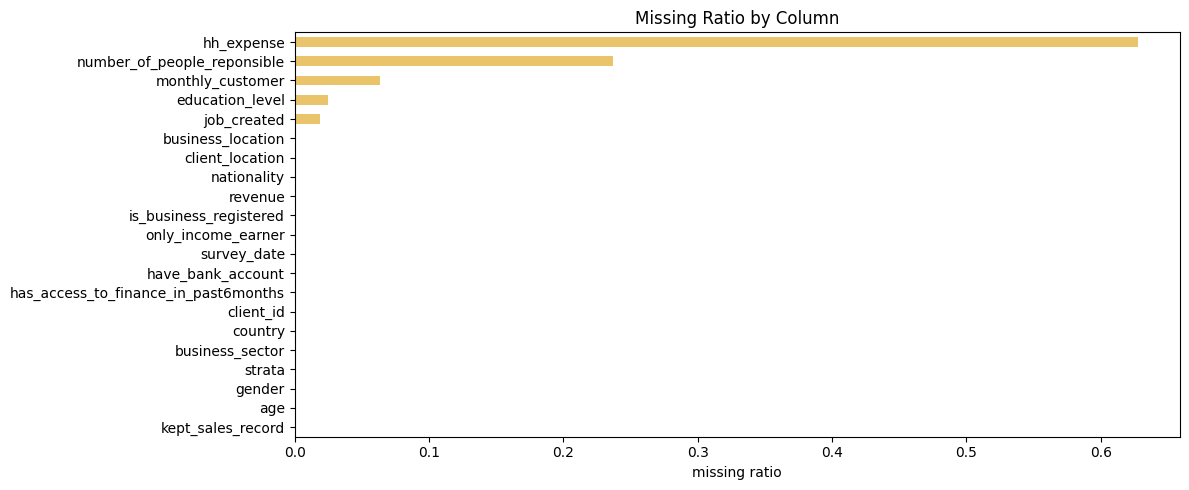

,count
country,
Rwanda,6264
Ethiopia,2145
South Sudan,567


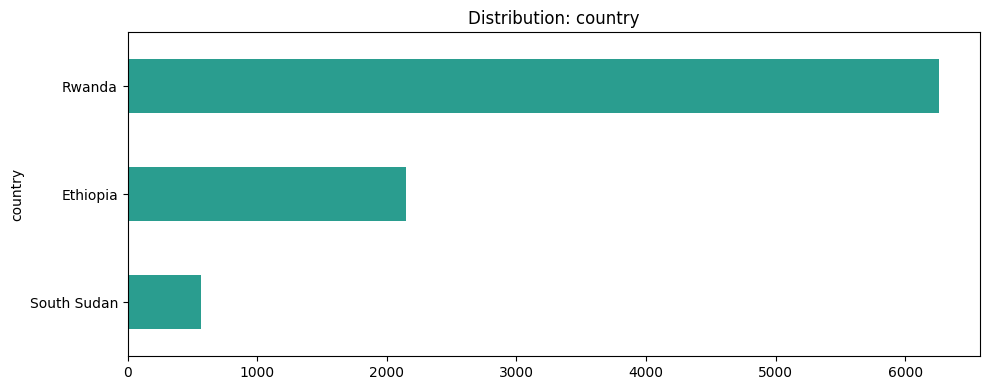

,count
gender,
Female,5516
Male,3460


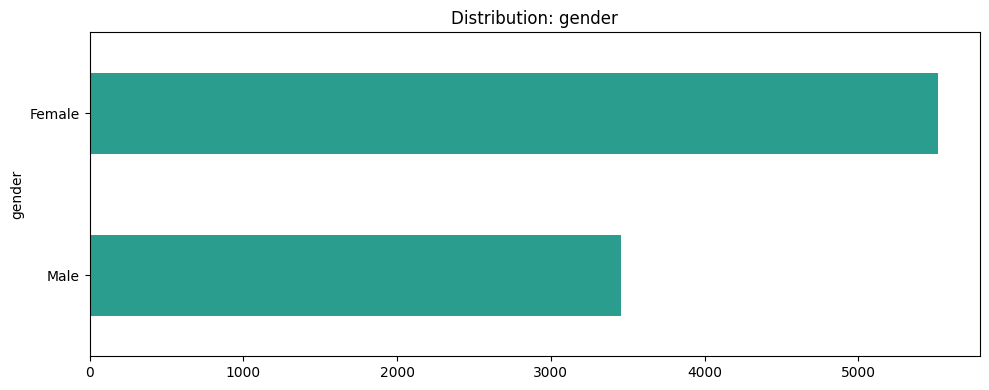

,count
strata,
Host,6008
Refugee,2968


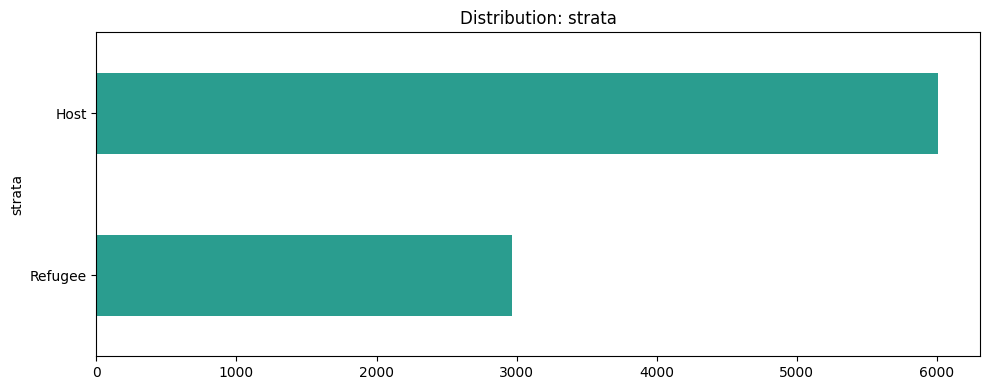

,count
nationality,
Rwandan,4990
Ethiopian,1016
Congolese,962
Sudanese,664
Somali,447
Burundian,370
South Sudanese,268
Eritrean,247
Yemeni,7


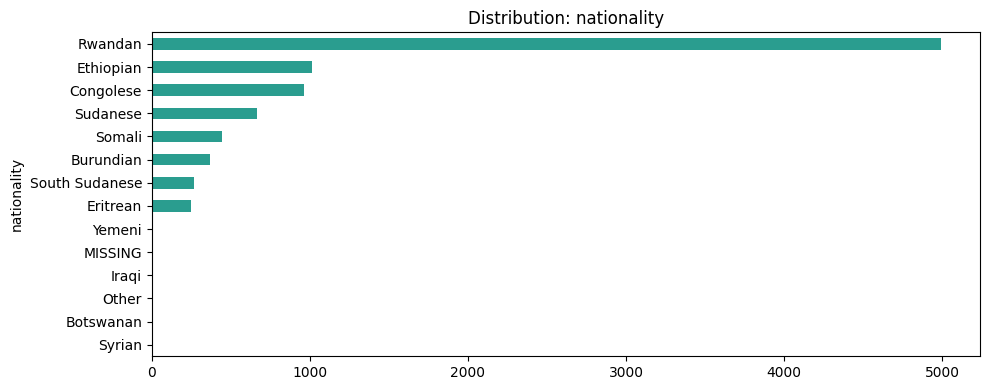

,count
education_level,
Attended High School,1981
Finished High School/Graduate,1210
Finished Primary School,1124
Attended Primary School,924
No Formal Education,665
Attended Primary,403
Finished Primary,326
Diploma,270
MISSING,221


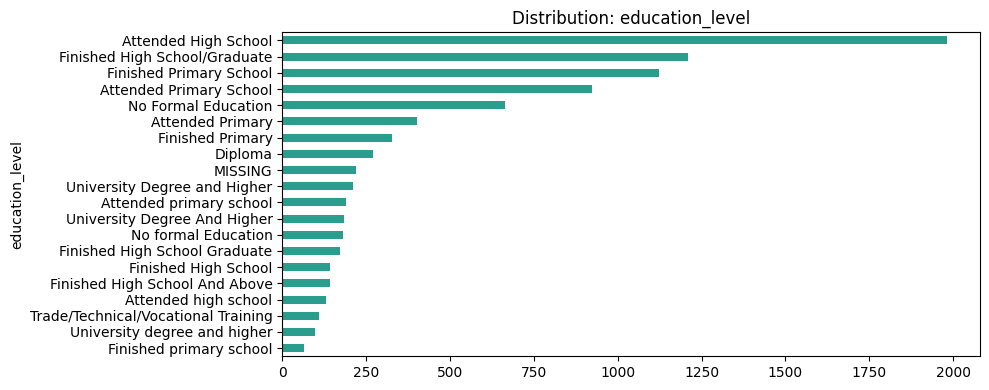

,count
client_location,
Musanze,695
Rusizi,644
Huye,618
Kayonza,473
Kebribeyah Town,361
Gatsibo,355
Nyamagabe,340
Karongi,333
Kirehe,331


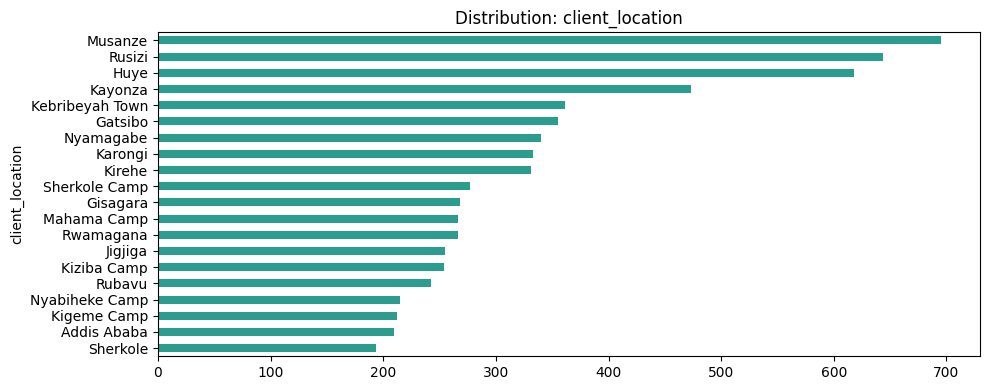

,count
business_location,
Musanze,670
Rusizi,644
Huye,616
Kayonza,475
Kebribeyah Town,366
Gatsibo,354
Kirehe,333
Karongi,331
Nyamagabe,328


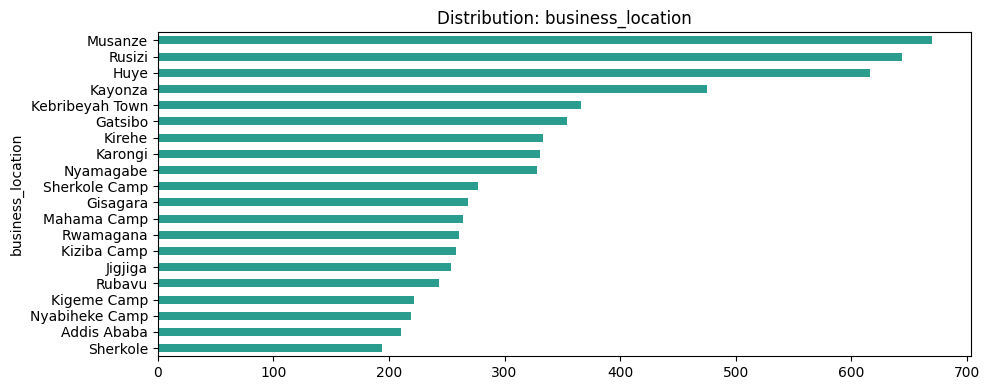

,count
business_sector,
Retail Sales and Grocery,2309
Fashion and Apparel,1201
Food and Beverage Retail,809
"Agribusiness,Processing,and Farming",782
"Tech,Digital Services,Ecommerce",540
Retail Sales & Grocery,330
Fashion And Apparel,268
Retail Shop,241
Retail Sales And Grocery,197


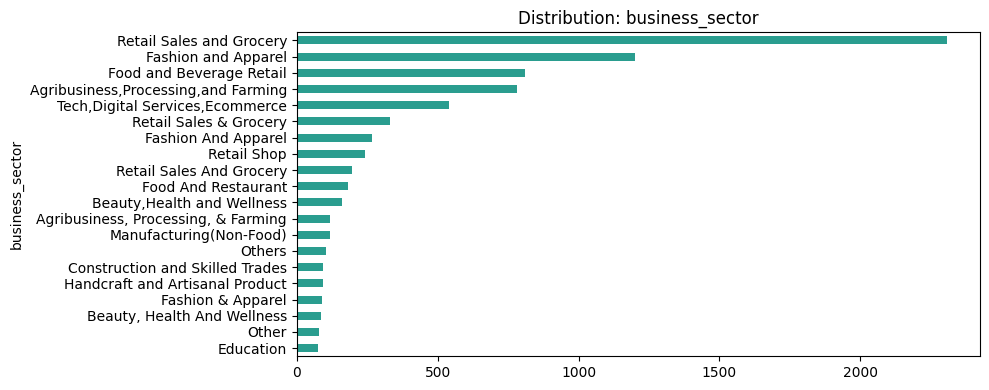

In [5]:
missing = df.isna().mean().sort_values(ascending=False)
display((missing * 100).round(2).rename('missing_pct').to_frame())

fig, ax = plt.subplots(figsize=(12, 5))
missing.sort_values(ascending=True).plot(kind='barh', ax=ax, color='#e9c46a')
ax.set_title('Missing Ratio by Column')
ax.set_xlabel('missing ratio')
plt.tight_layout()
plt.show()

demo_cols = ['country', 'gender', 'strata', 'nationality', 'education_level', 'client_location', 'business_location', 'business_sector']
for c in demo_cols:
    if c in df.columns:
        vc = df[c].fillna('MISSING').value_counts().head(20)
        display(vc.rename('count').to_frame())
        fig, ax = plt.subplots(figsize=(10, 4))
        vc.sort_values().plot(kind='barh', ax=ax, color='#2a9d8f')
        ax.set_title(f'Distribution: {c}')
        plt.tight_layout()
        plt.show()

,count,mean,std,min,1%,5%,50%,95%,99%,max
age,8976.0,34.507799,9.590219,18.0,19.00000,22.000,33.000000,52.000,61.000000,8.100000e+01
number_of_people_reponsible,6851.0,4.318202,3.068567,0.0,0.00000,1.000,4.000000,10.000,15.000000,2.500000e+01
monthly_customer,8403.0,784.544091,18429.604184,1.0,1.00000,3.000,195.000000,1200.000,2498.900000,1.200000e+06
job_created,8807.0,1.721358,4.396438,0.0,0.00000,0.000,1.000000,6.000,18.000000,1.850000e+02
revenue,8976.0,1023.705324,3619.326931,0.0,6.25475,27.115,329.000000,3615.381,11041.374250,1.527273e+05
hh_expense,3343.0,138.897556,339.992005,0.0,0.00000,0.000,86.614173,400.000,727.272727,1.685283e+04


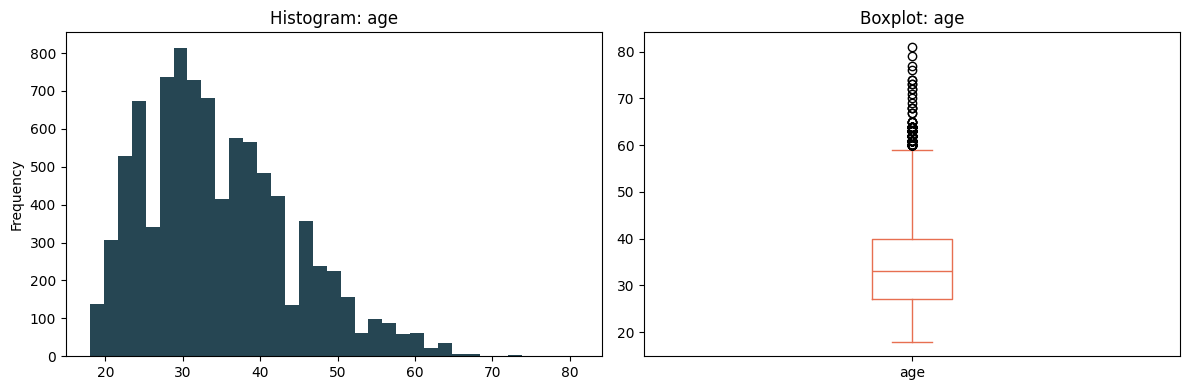

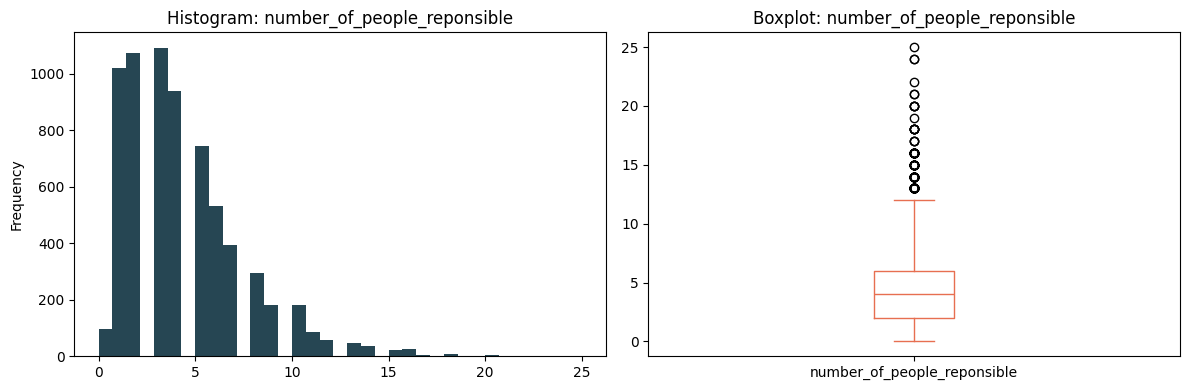

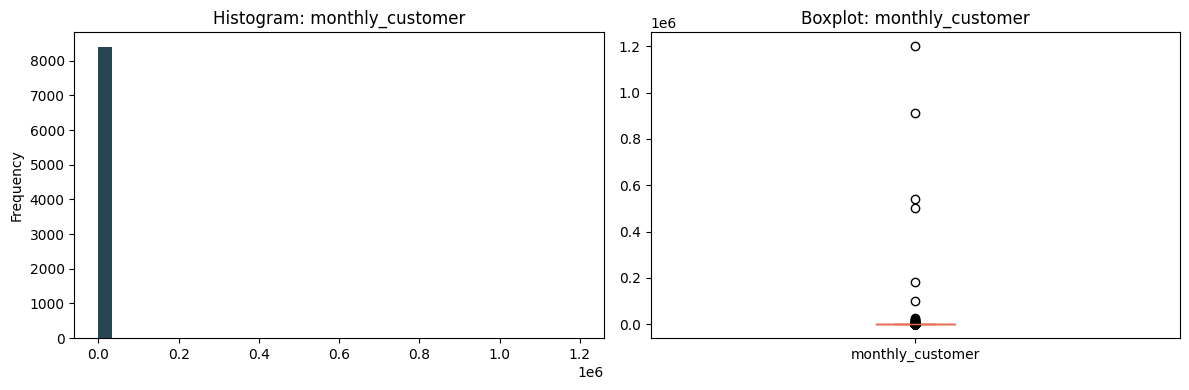

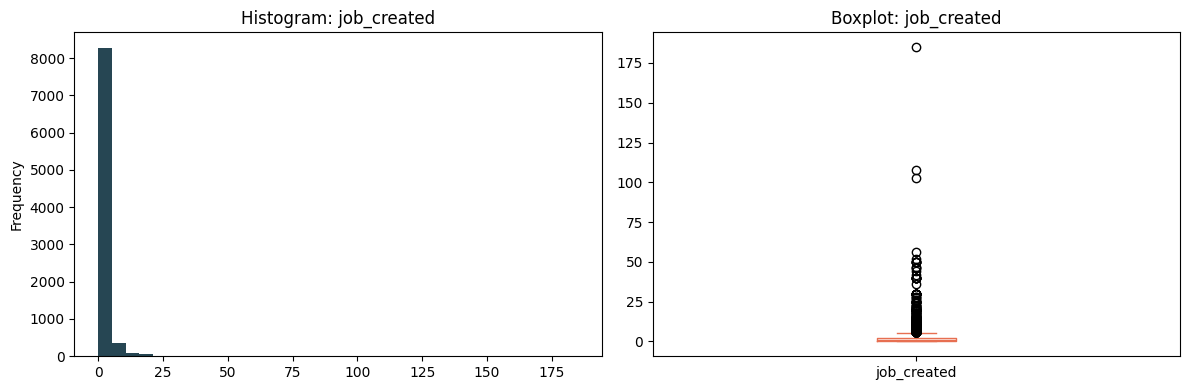

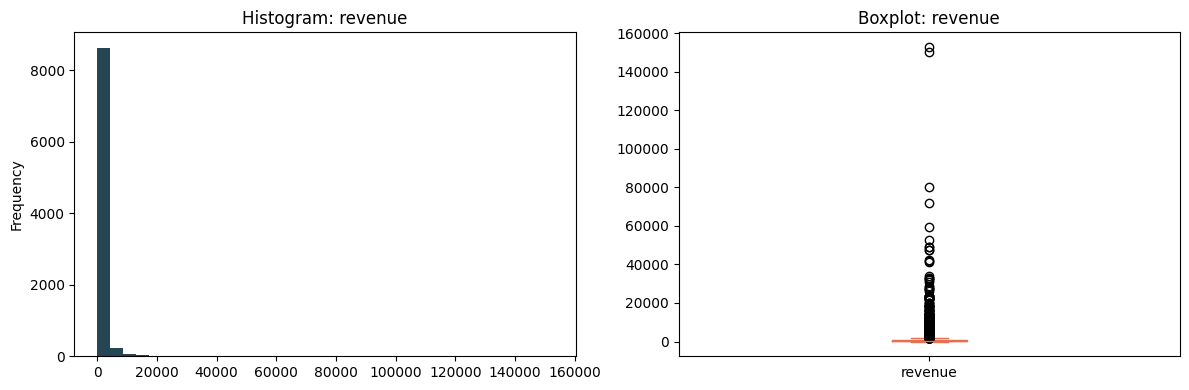

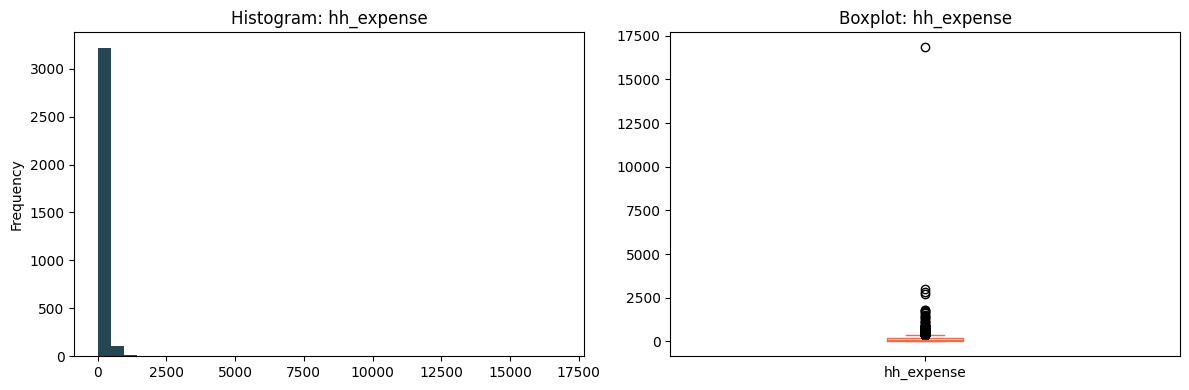

,revenue_expense_ratio
count,3132.000000
mean,58.645737
std,2516.770378
min,0.000000
25%,2.142857
50%,4.333333
75%,10.000000
max,140833.339984


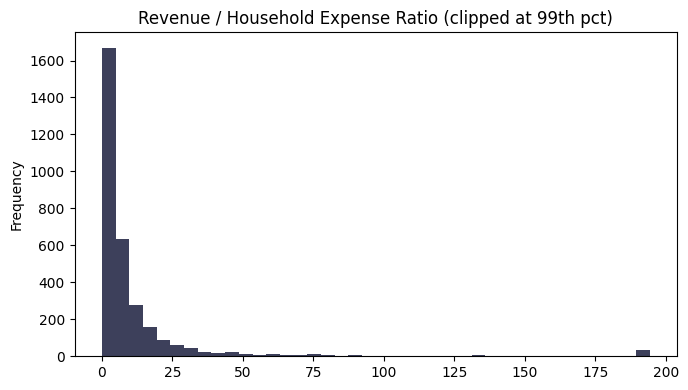

In [6]:
num_cols = [c for c in ['age', 'number_of_people_reponsible', 'monthly_customer', 'job_created', 'revenue', 'hh_expense'] if c in df.columns]
display(df[num_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

for c in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    df[c].dropna().plot(kind='hist', bins=35, ax=axes[0], color='#264653')
    axes[0].set_title(f'Histogram: {c}')
    df[c].dropna().plot(kind='box', ax=axes[1], color='#e76f51')
    axes[1].set_title(f'Boxplot: {c}')
    plt.tight_layout()
    plt.show()

if {'revenue', 'hh_expense'}.issubset(df.columns):
    ratio = df['revenue'] / df['hh_expense'].replace(0, np.nan)
    display(ratio.describe().rename('revenue_expense_ratio').to_frame())
    fig, ax = plt.subplots(figsize=(7, 4))
    ratio.dropna().clip(upper=ratio.quantile(0.99)).plot(kind='hist', bins=40, ax=ax, color='#3d405b')
    ax.set_title('Revenue / Household Expense Ratio (clipped at 99th pct)')
    plt.tight_layout()
    plt.show()

In [7]:
if {'business_sector', 'revenue'}.issubset(df.columns):
    sector_rev = df.groupby('business_sector')['revenue'].agg(['count', 'median', 'mean']).sort_values('median', ascending=False)
    display(sector_rev)

if {'business_location', 'job_created'}.issubset(df.columns):
    loc_jobs = df.groupby('business_location')['job_created'].agg(['count', 'mean', 'sum']).sort_values('mean', ascending=False)
    display(loc_jobs)

finance_cols = ['is_business_registered', 'has_access_to_finance_in_past6months', 'have_bank_account', 'kept_sales_record']
available_fin = [c for c in finance_cols if c in df.columns]
for c in available_fin:
    print(f'Value counts for {c}:')
    display(df[c].fillna('missing').value_counts(dropna=False).rename('count').to_frame())

if set(['have_bank_account', 'has_access_to_finance_in_past6months']).issubset(df.columns):
    ctab = pd.crosstab(df['have_bank_account'], df['has_access_to_finance_in_past6months'], normalize='index')
    display((ctab * 100).round(2))

,count,median,mean
business_sector,,,
Wholesale And General Trading,13,7090.909091,11893.706294
Wholesale and General Trading,7,3275.590551,6323.413517
Energy,2,2811.181818,2811.181818
Retail Or Wholesale Shop,2,2509.090909,2509.090909
Health Care,6,2045.454545,9767.048827
...,...,...,...
Education,77,140.581068,467.972231
Manufacturing(Non-Food),117,108.461000,730.039718
Beauty And Cosmetic,10,94.339623,199.116638


,count,mean,sum
business_location,,,
Lideta,2,12.000000,24.0
Addis Ketema,2,9.500000,19.0
Kirkos,13,7.923077,103.0
Lemi Kura,68,7.000000,476.0
Nyabihu,110,6.600000,726.0
...,...,...,...
Nyanza,78,0.294872,23.0
Rusizi,644,0.265528,171.0
Mangalla IDP camp,38,0.052632,2.0


Value counts for is_business_registered:


,count
is_business_registered,
nan,5981
no,1769
yes,1226


Value counts for has_access_to_finance_in_past6months:


...

Value counts for have_bank_account:


,count
have_bank_account,
nan,5412
yes,2276
no,1288


Value counts for kept_sales_record:


,count
kept_sales_record,
yes,6663
no,2304
nan,9


has_access_to_finance_in_past6months,nan,no,yes
have_bank_account,,,
nan,99.94,0.06,0.00
no,12.73,71.89,15.37
yes,5.98,66.65,27.37


In [8]:
quality_flags = {}

if {'age'}.issubset(df.columns):
    quality_flags['age_lt_14'] = int((df['age'] < 14).sum())
    quality_flags['age_gt_100'] = int((df['age'] > 100).sum())

for c in ['revenue', 'hh_expense', 'monthly_customer', 'job_created']:
    if c in df.columns:
        quality_flags[f'negative_{c}'] = int((df[c] < 0).sum())

display(pd.Series(quality_flags, name='count').to_frame())

print('Executive Summary Prompts:')
print('- Identify baseline vulnerability segments with low finance access and low record-keeping rates.')
print('- Focus support by camp and sector where revenue is low and job creation is stagnant.')
print('- Check whether household burden is outpacing business inflows using ratio metrics.')

,count
age_lt_14,0
age_gt_100,0
negative_revenue,0
negative_hh_expense,0
negative_monthly_customer,0
negative_job_created,0


Executive Summary Prompts:
- Identify baseline vulnerability segments with low finance access and low record-keeping rates.
- Focus support by camp and sector where revenue is low and job creation is stagnant.
- Check whether household burden is outpacing business inflows using ratio metrics.
